In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is working 🚀")


Environment is working 🚀


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load data
df = pd.read_csv("../data/raw/Students Social Media Addiction.csv")

# Create target
df["High_Addiction"] = (df["Addicted_Score"] >= 7).astype(int)

# Prepare features
X = df.drop(["Student_ID", "Addicted_Score", "High_Addiction", "Country"], axis=1)
y = df["High_Addiction"]

# Encode
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, min_samples_split=10, n_estimators=200,
                       random_state=42)

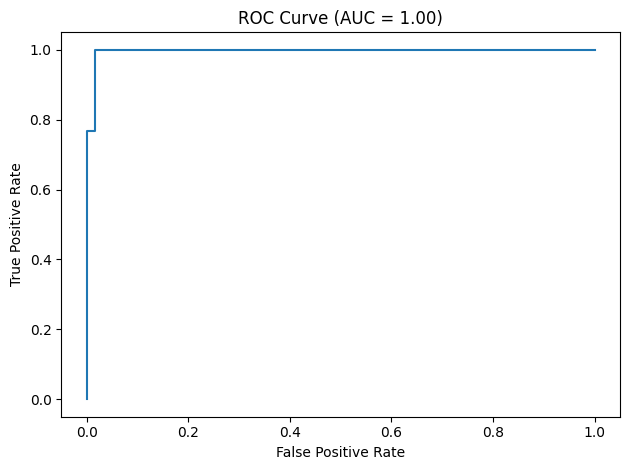

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.tight_layout()

plt.savefig("../assets/roc_curve.png")
plt.show()


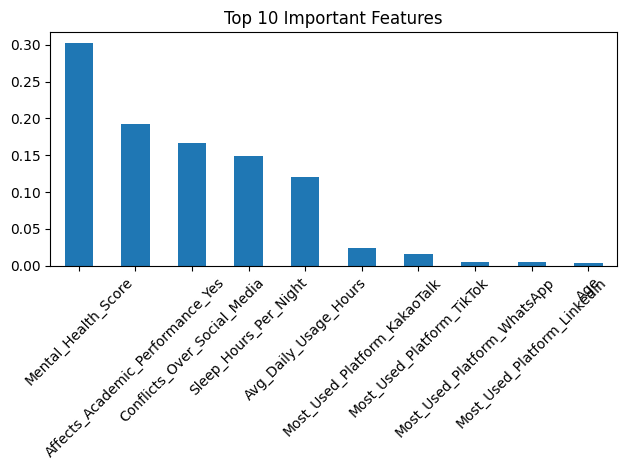

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

# Plot
plt.figure()
importance.plot(kind="bar")
plt.title("Top 10 Important Features")
plt.xticks(rotation=45)
plt.tight_layout()

# Save image
plt.savefig("../assets/feature_importance.png")

plt.show()
